En este cuaderno probaremos diversas normalizaciones junto al modelo basado en Redes neuronales Densas.
Primero cargamos los datos que usaremos.

In [44]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
import matplotlib.pyplot as plt
import os

os.environ["NUMEXPR_MAX_THREADS"] = "8"
os.environ["NUMEXPR_NUM_THREADS"] = "8"

import numpy as np
from pathlib import Path

processed_path = Path("../data/splits/2026-08-16_processed_data_no_duplicates.npz")

data = np.load(processed_path)

print(data.files)

['X_train', 'X_val', 'X_test', 'X_id_train', 'X_id_val', 'X_id_test', 'X_err_train', 'X_err_val', 'X_err_test', 'y_train', 'y_val', 'y_test', 'y_id_train', 'y_id_val', 'y_id_test', 'y_ivar_train', 'y_ivar_val', 'y_ivar_test', 'gaia_wavelength', 'sdss_wavelength']


In [45]:
# Datos de Gaia
X_train = data["X_train"]
X_val = data["X_val"]
X_test = data["X_test"]

# Errores de Gaia
X_err_train = data["X_err_train"]
X_err_val = data["X_err_val"]
X_err_test = data["X_err_test"]

# IDs de Gaia
X_id_train = data["X_id_train"]
X_id_val = data["X_id_val"]
X_id_test = data["X_id_test"]

# Datos de SDSS
y_train = data["y_train"]
y_val = data["y_val"]
y_test = data["y_test"]

# IDs de SDSS
y_id_train = data["y_id_train"]
y_id_val = data["y_id_val"]
y_id_test = data["y_id_test"]

# Longitudes de onda
gaia_wavelength = data["gaia_wavelength"]
sdss_wavelength = data["sdss_wavelength"]

Probamos ahora una normalización basada en la media aritmética de todos los espectros observados en el conjunto de entrenamiento. 

In [3]:
# Normalizamos los datos
X_mean = X_train.mean()
X_std = X_train.std()

y_mean = y_train.mean()
y_std = y_train.std()

X_train_norm_global = (X_train - X_mean) / X_std
X_val_norm_global = (X_val - X_mean) / X_std
X_test_norm_global = (X_test - X_mean) / X_std

y_train_norm_global = (y_train - y_mean) / y_std
y_val_norm_global = (y_val - y_mean) / y_std
y_test_norm_global = (y_test - y_mean) / y_std

In [4]:
n_gaia = X_train.shape[1]
n_sdss = y_train.shape[1]

# Definimos la estructura del modelo a usar
model = models.Sequential([
    layers.Input(shape=(n_gaia,)),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),
    
    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

model.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm = 1.0),
    loss= tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       103,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,460,586 (20.83 MB)

 Trainable params: 5,460,586 (20.83 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta = 1e-4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

Entrenamos el modelo

In [6]:
history_norm_global = model.fit(
    X_train_norm_global,
    y_train_norm_global,
    validation_data=(X_val_norm_global, y_val_norm_global),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop,reduce_lr],
    verbose=1
)

Epoch 1/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 48s 90ms/step - loss: 0.0675 - mae: 0.2131 - mse: 0.1637 - val_loss: 0.0139 - val_mae: 0.0973 - val_mse: 0.0300 - learning_rate: 1.0000e-04
Epoch 2/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 47s 91ms/step - loss: 0.0131 - mae: 0.0928 - mse: 0.0285 - val_loss: 0.0121 - val_mae: 0.0870 - val_mse: 0.0264 - learning_rate: 1.0000e-04
Epoch 3/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 39s 76ms/step - loss: 0.0117 - mae: 0.0883 - mse: 0.0253 - val_loss: 0.0129 - val_mae: 0.0905 - val_mse: 0.0282 - learning_rate: 1.0000e-04
Epoch 4/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 38s 74ms/step - loss: 0.0118 - mae: 0.0899 - mse: 0.0253 - val_loss: 0.0107 - val_mae: 0.0832 - val_mse: 0.0235 - learning_rate: 1.0000e-04
Epoch 5/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 35s 67ms/step - loss: 0.0108 - mae: 0.0855 - mse: 0.0232 - val_loss: 0.0111 - val_mae: 0.0830 - val_mse: 0.0244 - learning_rate: 1.0000e-04
Epoch 6/50
510/511 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0106 - mae: 0.0844 - mse: 0.0226
Epoc

Graficamos la evolución de las variables estudiadas en el modelo.

In [7]:
# Importamos funciones a usar para analizar resultados
from model_functions import (
    plot_training_metrics,
    plot_prediction_example,
    plot_worst_best_predictions
)

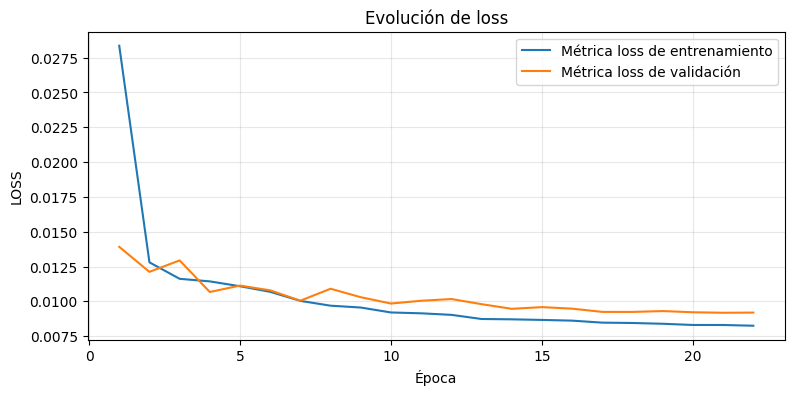

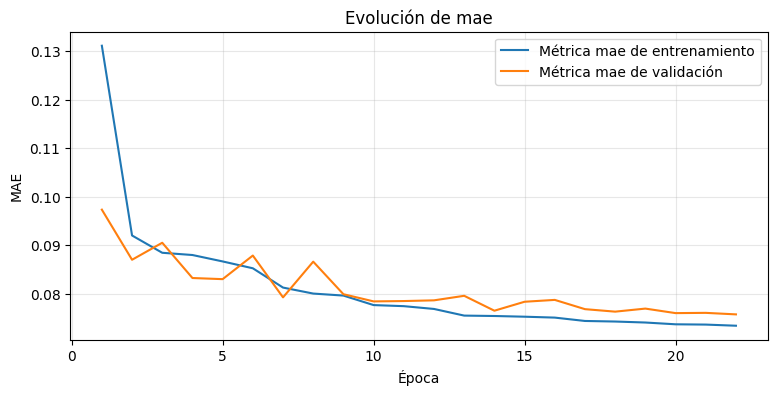

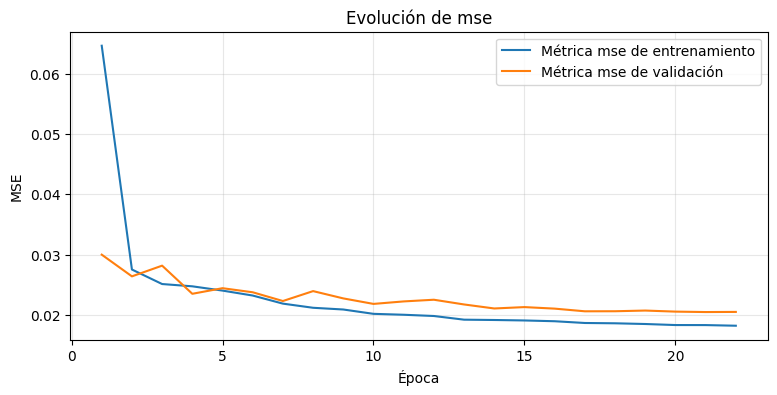

In [8]:
model_data_norm_global = history_norm_global.history
plot_training_metrics(model_data_norm_global)

In [9]:
# Predecimos sobre el conjunto de test
y_pred_norm_global = model.predict(X_test_norm_global)
y_pred_global = y_pred_norm_global * y_std + y_mean

128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


Graficamos un par de ejemplos

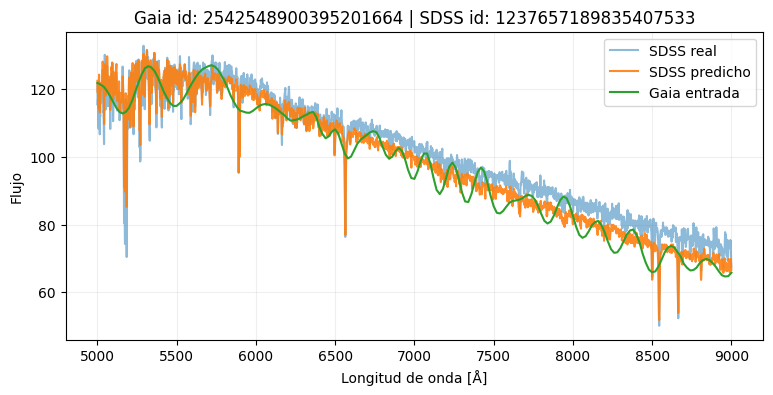

In [10]:
plot_prediction_example(
    245,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_global,
    y_id_test,
    X_test,
    X_id_test
)

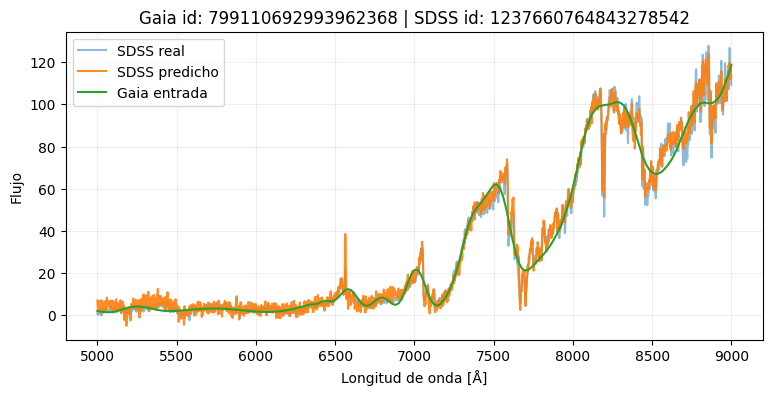

In [11]:
plot_prediction_example(
    10,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_global,
    y_id_test,
    X_test,
    X_id_test
)

In [12]:
test_loss, test_mae, test_mse = model.evaluate(
    X_test_norm_global,
    y_test_norm_global,
    verbose=1
)

128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0094 - mae: 0.0769 - mse: 0.0211


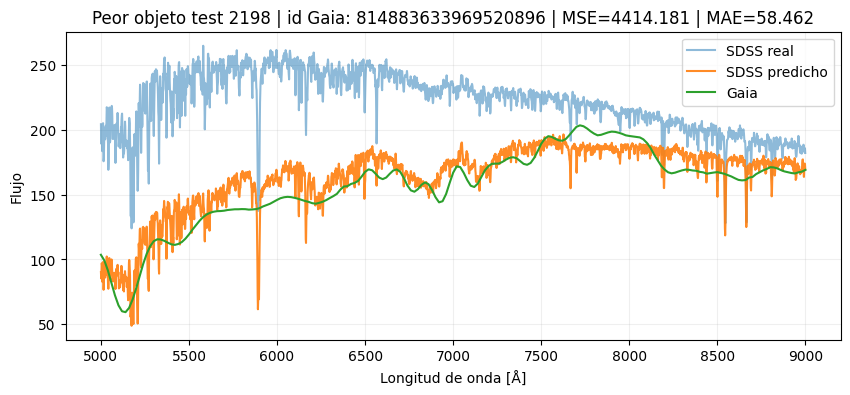

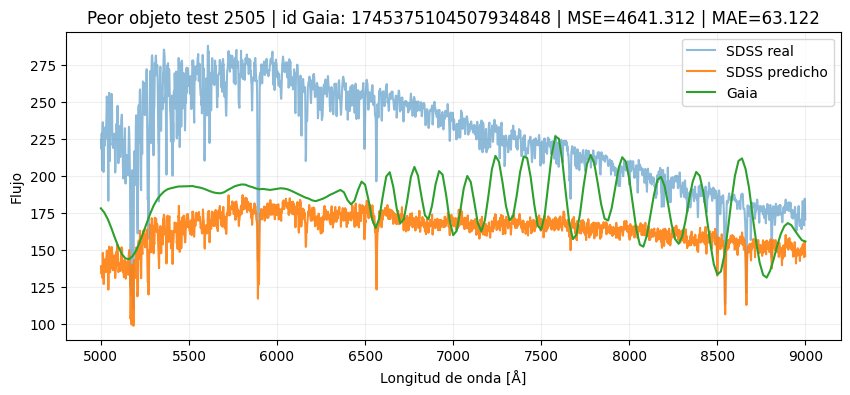

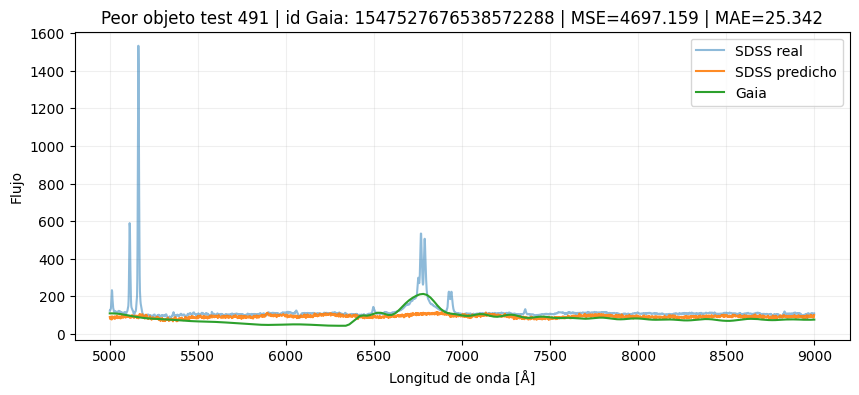

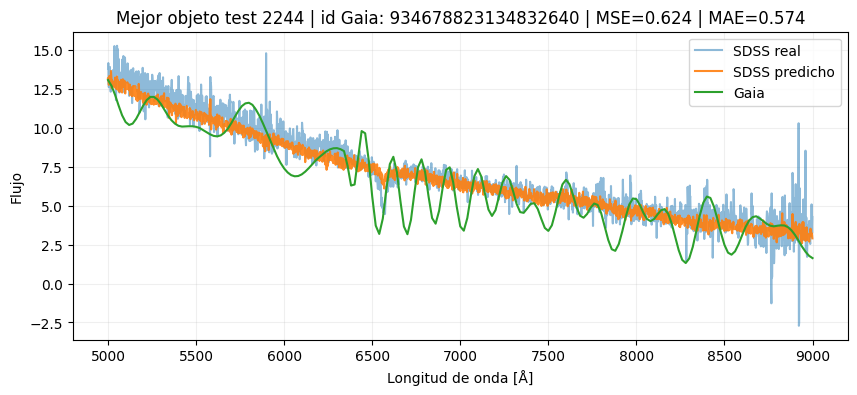

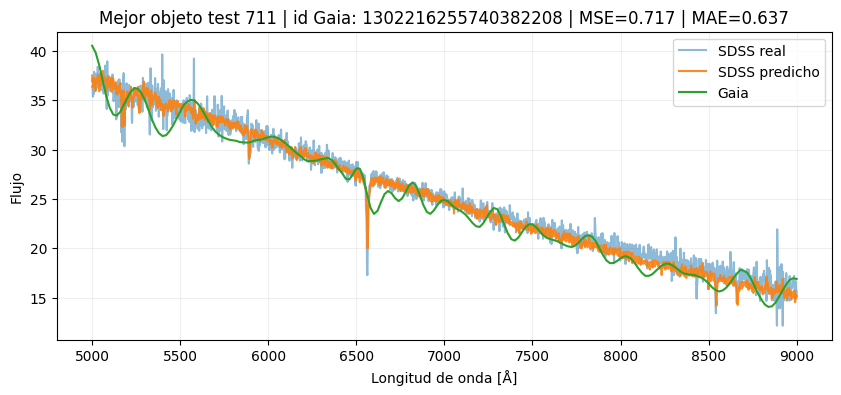

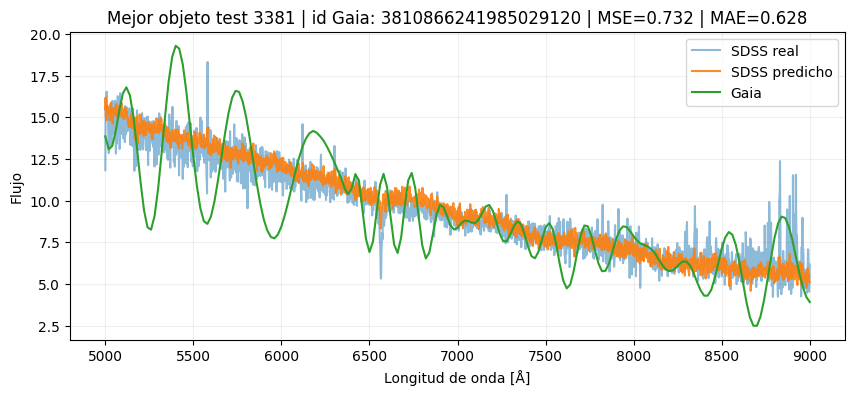

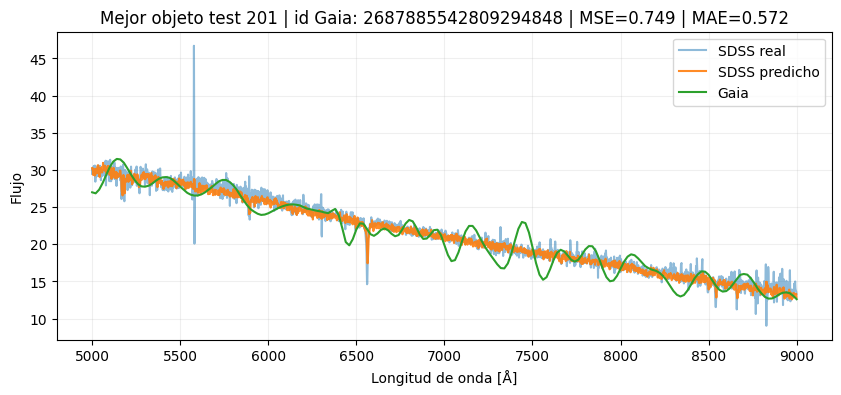

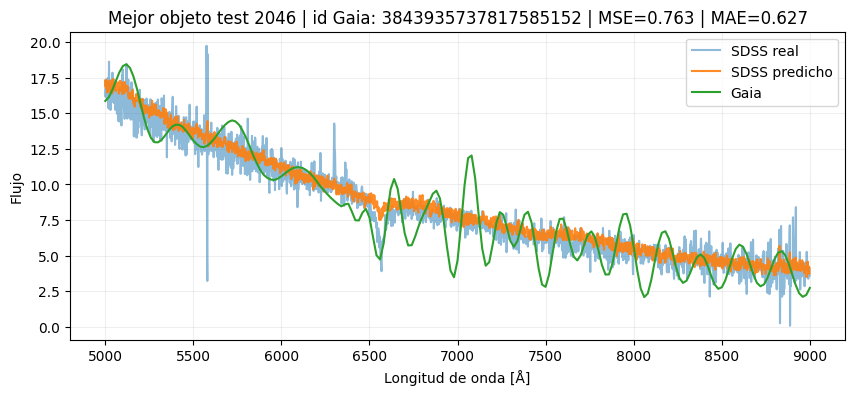

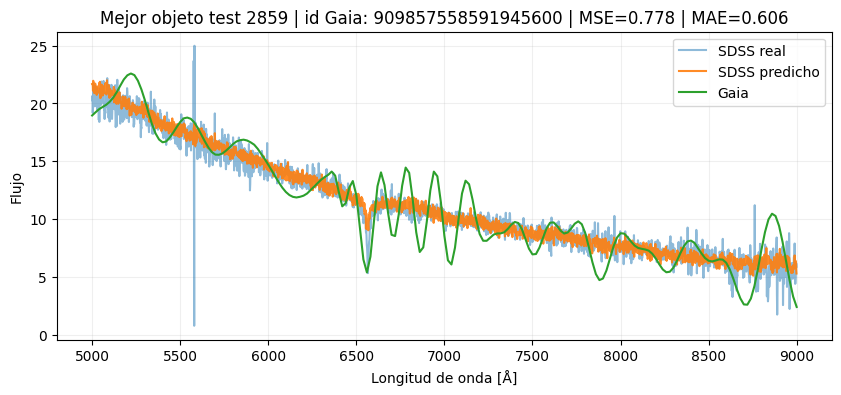

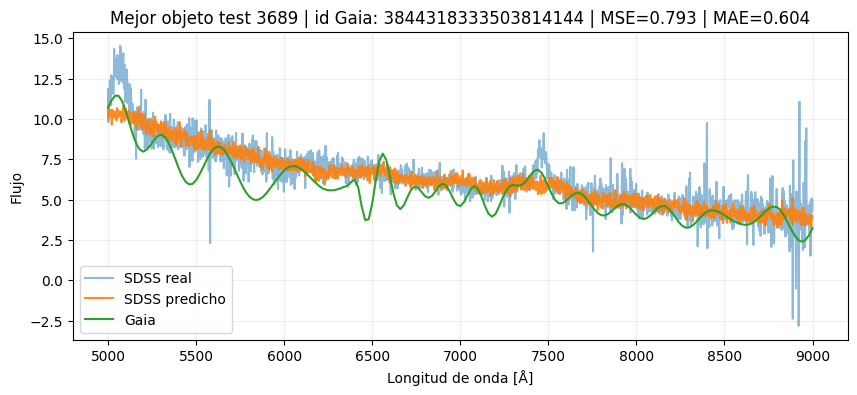

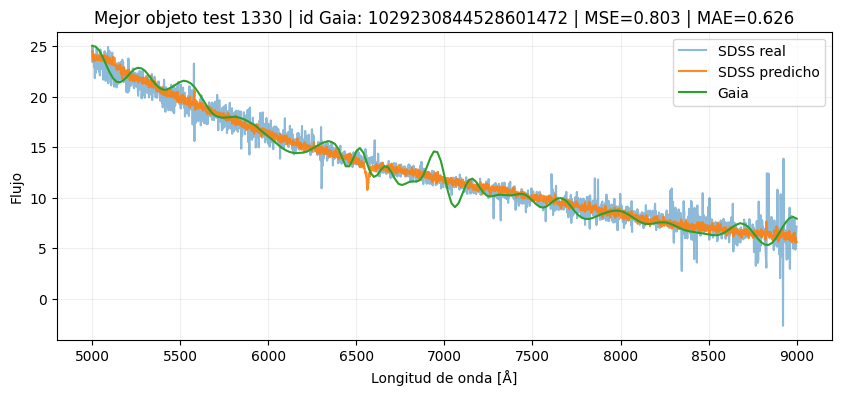

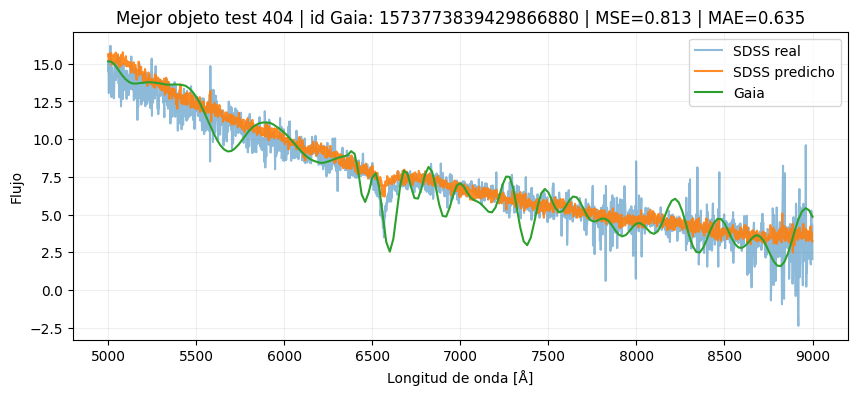

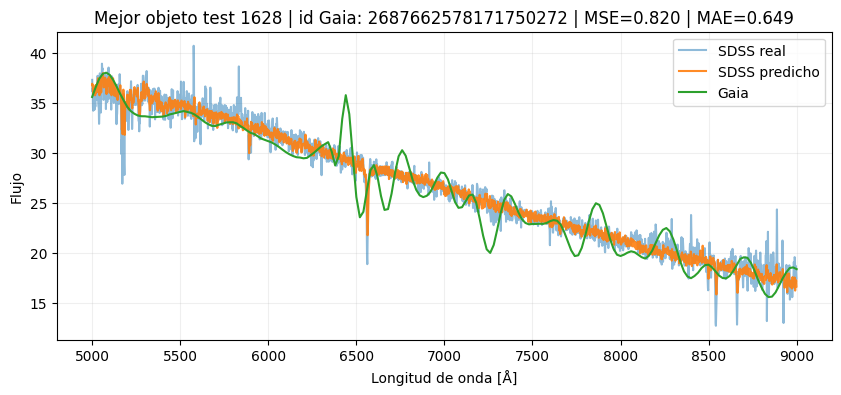

In [13]:
plot_worst_best_predictions(
    y_test,
    y_pred_global,
    X_test,
    X_id_test,
    sdss_wavelength,
    gaia_wavelength,
    3
)

Añadimos código para comprobar los valores sacados con iSpec del espectro real y predicho. 

In [56]:
import sys
from pathlib import Path

ISPEC_FUNCTIONS_DIR = Path(
    "../solution/models"
)

if str(ISPEC_FUNCTIONS_DIR) not in sys.path:
    sys.path.insert(0, str(ISPEC_FUNCTIONS_DIR))

In [62]:
# Importamos Funciones iSpec
from iSpec_functions import (
    load_ispec_resources,
    analyze_sample_real_vs_pred,
    analyze_ispec_errors
)

In [63]:
# Recargamos si ha habido modificaciones
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [59]:
# Cargamos Resources
resources = load_ispec_resources()


Recursos de iSpec cargados correctamente.


In [18]:
from astropy.table import Table
# Cargamos la tabla de Gaia guardada en local
gaia_data_path = Path("../data/gaia_data.ecsv")

gaia_data_table = Table.read(
    gaia_data_path,
    format="ascii.ecsv"
)

# Pasamos a dataframe
gaia_data_df = gaia_data_table.to_pandas()

In [47]:
# Analizamos y devolvemos DF con valores ajustados a los espectros
results_df = analyze_sample_real_vs_pred(   
    y_test,
    y_pred_global,
    X_id_test,
    gaia_data_df,
    sdss_wavelength,
    resources,
    sample_size=300
)

Espectros analizados:   0%|          | 0/300 [00:00<?, ?cuerpos estelares/s]

Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE


[2026-08-22 11:42:12,789] [WARNING] [atmospheres:_interpolate:114]: Target point '4642.083931059987 5.5 -0.6693910997863578' is out of bound, using the closest
[2026-08-22 11:43:15,296] [WARNING] [atmospheres:_interpolate:114]: Target point '4941.116963000216 5.420738682721558 -0.43848983890650706' is out of bound, using the closest
[2026-08-22 11:43:42,891] [WARNING] [atmospheres:_interpolate:114]: Target point '5006.222906645974 5.413800000424778 -0.42792597394714504' is out of bound, using the closest


Only LTE


[2026-08-22 11:44:12,395] [WARNING] [atmospheres:_interpolate:114]: Target point '4677.476063405164 5.5 -0.6645062315775174' is out of bound, using the closest
[2026-08-22 11:45:14,734] [WARNING] [atmospheres:_interpolate:114]: Target point '4838.270139197378 5.457943108162064 -0.9341804582310047' is out of bound, using the closest


...

Only LTE
Only LTE
Only LTE
Only LTE
Only LTE


[2026-08-22 23:09:07,591] [WARNING] [atmospheres:_interpolate:114]: Target point '4031.7701301480015 5.5 -1.1914202085137093' is out of bound, using the closest


Only LTE


[2026-08-22 23:10:48,608] [WARNING] [atmospheres:_interpolate:114]: Target point '4188.601879673723 5.5 -1.0958248405585733' is out of bound, using the closest
[2026-08-22 23:11:29,826] [WARNING] [atmospheres:_interpolate:114]: Target point '4020.929336212036 5.5 -2.3355017117749353' is out of bound, using the closest


Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE


In [48]:
display(results_df)


,test_index,source_id,gaia_teff,gaia_logg,gaia_mh,real_teff,real_logg,real_mh,pred_teff,pred_logg,pred_mh,delta_teff,delta_logg,delta_mh
0,63,152047619011614592,5181.031738,4.6678,-0.8967,5357.008345,4.810525,-0.969029,5207.892012,4.650596,-0.845216,-149.116333,-0.159929,0.123813
1,3594,1297820202093665792,5753.429688,4.6788,-1.1166,5813.224308,4.707357,-1.129837,5833.319376,4.691286,-1.182968,20.095067,-0.016072,-0.053131
2,1248,580515167071431424,6104.623047,4.6595,-1.1587,6139.737527,4.695610,-1.160715,6143.460560,4.693683,-1.154072,3.723034,-0.001926,0.006642
3,3984,1548356295989132032,6033.668945,4.1655,-0.6890,6042.269395,4.167486,-0.687873,6037.814270,4.168524,-0.688935,-4.455124,0.001037,-0.001062
4,1597,147920842634097664,6010.371582,4.2697,-0.6194,6037.687771,4.298310,-0.610908,6037.222091,4.298165,-0.613242,-0.465680,-0.000145,-0.002334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,248,701577998655719296,7057.899902,4.3934,-3.8241,7097.933193,4.398294,-3.728924,7091.888609,4.398323,-3.798548,-6.044585,0.000028,-0.069624
296,384,705712987010613632,6785.309570,4.2019,-0.8287,6807.625634,4.240117,-0.844802,6819.446982,4.234658,-0.976064,11.821348,-0.005459,-0.131262
297,2884,3844276521997562624,6694.334961,4.3380,-2.5967,6698.845693,4.344018,-2.719115,6698.466811,4.341810,-2.975191,-0.378881,-0.002208,-0.256076
298,2298,1490021667920271872,6651.660645,4.5889,-3.2864,6652.495268,4.589173,-3.262428,6653.135675,4.589788,-3.275865,0.640407,0.000615,-0.013436


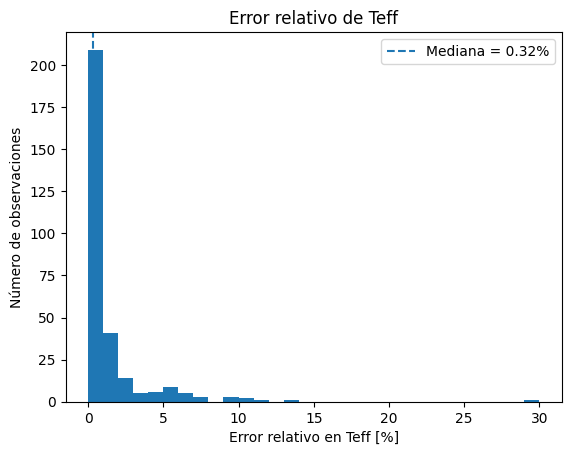

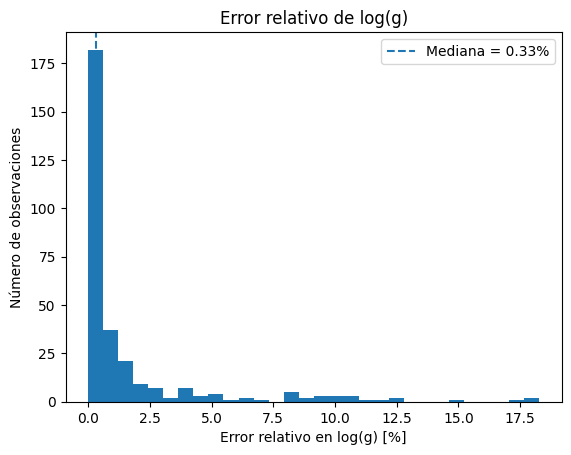

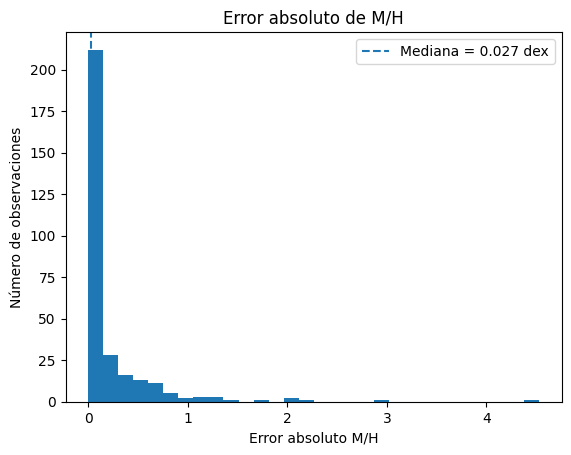

In [49]:
error_df = analyze_ispec_errors(results_df)

In [50]:
display(error_df)

,test_index,source_id,gaia_teff,gaia_logg,gaia_mh,real_teff,real_logg,real_mh,pred_teff,pred_logg,pred_mh,delta_teff,delta_logg,delta_mh,abs_error_teff,abs_error_logg,abs_error_mh,rel_error_teff,rel_error_logg
0,63,152047619011614592,5181.031738,4.6678,-0.8967,5357.008345,4.810525,-0.969029,5207.892012,4.650596,-0.845216,-149.116333,-0.159929,0.123813,149.116333,0.159929,0.123813,2.783575,3.324558
1,3594,1297820202093665792,5753.429688,4.6788,-1.1166,5813.224308,4.707357,-1.129837,5833.319376,4.691286,-1.182968,20.095067,-0.016072,-0.053131,20.095067,0.016072,0.053131,0.345679,0.341418
2,1248,580515167071431424,6104.623047,4.6595,-1.1587,6139.737527,4.695610,-1.160715,6143.460560,4.693683,-1.154072,3.723034,-0.001926,0.006642,3.723034,0.001926,0.006642,0.060638,0.041022
3,3984,1548356295989132032,6033.668945,4.1655,-0.6890,6042.269395,4.167486,-0.687873,6037.814270,4.168524,-0.688935,-4.455124,0.001037,-0.001062,4.455124,0.001037,0.001062,0.073733,0.024892
4,1597,147920842634097664,6010.371582,4.2697,-0.6194,6037.687771,4.298310,-0.610908,6037.222091,4.298165,-0.613242,-0.465680,-0.000145,-0.002334,0.465680,0.000145,0.002334,0.007713,0.003369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,248,701577998655719296,7057.899902,4.3934,-3.8241,7097.933193,4.398294,-3.728924,7091.888609,4.398323,-3.798548,-6.044585,0.000028,-0.069624,6.044585,0.000028,0.069624,0.085160,0.000643
296,384,705712987010613632,6785.309570,4.2019,-0.8287,6807.625634,4.240117,-0.844802,6819.446982,4.234658,-0.976064,11.821348,-0.005459,-0.131262,11.821348,0.005459,0.131262,0.173649,0.128752
297,2884,3844276521997562624,6694.334961,4.3380,-2.5967,6698.845693,4.344018,-2.719115,6698.466811,4.341810,-2.975191,-0.378881,-0.002208,-0.256076,0.378881,0.002208,0.256076,0.005656,0.050829
298,2298,1490021667920271872,6651.660645,4.5889,-3.2864,6652.495268,4.589173,-3.262428,6653.135675,4.589788,-3.275865,0.640407,0.000615,-0.013436,0.640407,0.000615,0.013436,0.009627,0.013399


Intentamos el mismo modelo pero con normalización espectro a espectro con la mediana.

In [23]:
X_scale_train = np.nanmedian(np.abs(X_train), axis=1, keepdims=True)
X_scale_val = np.nanmedian(np.abs(X_val), axis=1, keepdims=True)
X_scale_test = np.nanmedian(np.abs(X_test), axis=1, keepdims=True)

y_scale_train = np.nanmedian(np.abs(y_train), axis=1, keepdims=True)
y_scale_val = np.nanmedian(np.abs(y_val), axis=1, keepdims=True)
y_scale_test = np.nanmedian(np.abs(y_test), axis=1, keepdims=True)

X_train_norm_median_spec = X_train / X_scale_train
X_val_norm_median_spec = X_val / X_scale_val
X_test_norm_median_spec = X_test / X_scale_test

y_train_norm_median_spec = y_train / y_scale_train
y_val_norm_median_spec = y_val / y_scale_val
y_test_norm_median_spec = y_test / y_scale_test

In [24]:
n_gaia = X_train.shape[1]
n_sdss = y_train.shape[1]

model_median_spec = models.Sequential([
    layers.Input(shape=(n_gaia,)),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),
    
    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

model_median_spec.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm = 1.0),
    loss= tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_median_spec.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 512)            │       103,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,460,586 (20.83 MB)

 Trainable params: 5,460,586 (20.83 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Entrenamos el modelo
history = model_median_spec.fit(
    X_train_norm_median_spec,
    y_train_norm_median_spec,
    validation_data=(X_val_norm_median_spec, y_val_norm_median_spec),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop,reduce_lr],
    verbose=1
)

Epoch 1/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - loss: 0.0649 - mae: 0.1949 - mse: 0.1448 - val_loss: 0.0049 - val_mae: 0.0550 - val_mse: 0.0147 - learning_rate: 1.0000e-04
Epoch 2/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - loss: 0.0046 - mae: 0.0517 - mse: 0.0117 - val_loss: 0.0046 - val_mae: 0.0522 - val_mse: 0.0140 - learning_rate: 1.0000e-04
Epoch 3/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - loss: 0.0044 - mae: 0.0504 - mse: 0.0116 - val_loss: 0.0042 - val_mae: 0.0490 - val_mse: 0.0132 - learning_rate: 1.0000e-04
Epoch 4/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - loss: 0.0042 - mae: 0.0492 - mse: 0.0111 - val_loss: 0.0039 - val_mae: 0.0465 - val_mse: 0.0125 - learning_rate: 1.0000e-04
Epoch 5/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - loss: 0.0041 - mae: 0.0492 - mse: 0.0109 - val_loss: 0.0042 - val_mae: 0.0520 - val_mse: 0.0129 - learning_rate: 1.0000e-04
Epoch 6/50
509/511 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0038 - mae: 0.0481 - mse: 0.0100
Epoc

In [26]:
y_pred_norm_median_spec = model_median_spec.predict(X_test_norm_median_spec)
y_pred_median_spec = y_pred_norm_median_spec * y_scale_test

  1/128 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step

128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [27]:
test_loss_median_spec, test_mae_median_spec, test_mse_median_spec = model_median_spec.evaluate(
    X_test_norm_median_spec,
    y_test_norm_median_spec,
    verbose=1
)

128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0032 - mae: 0.0423 - mse: 0.0091


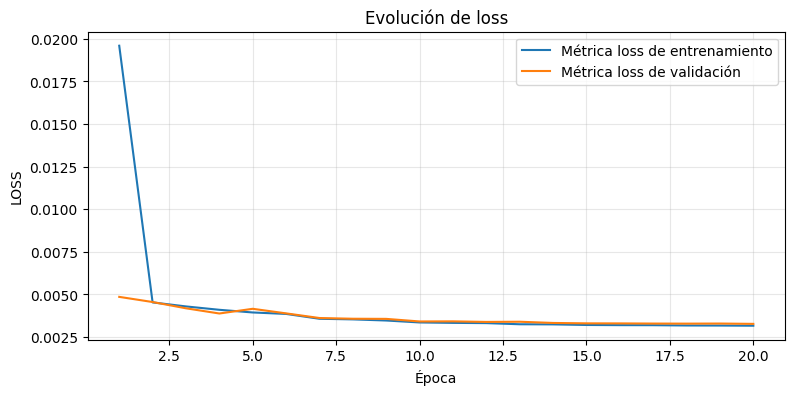

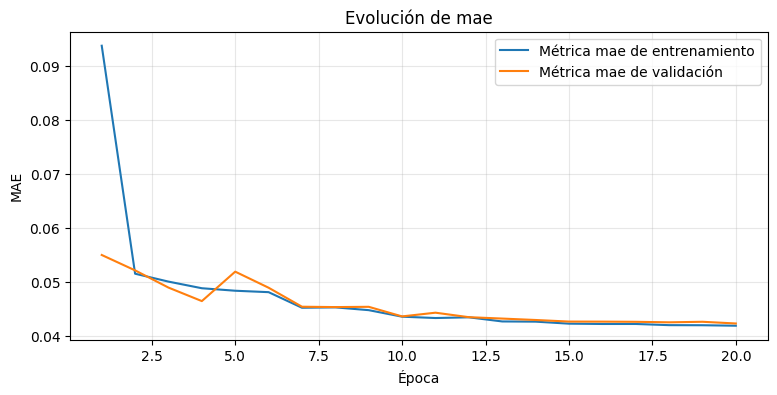

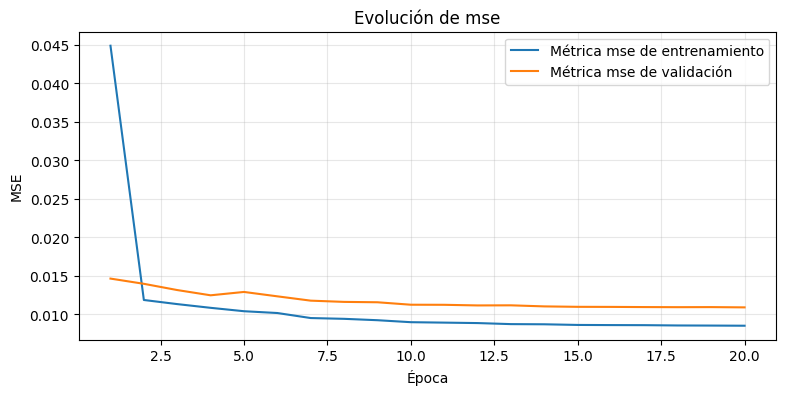

In [28]:
model_data_median_spec = history.history
plot_training_metrics(model_data_median_spec)

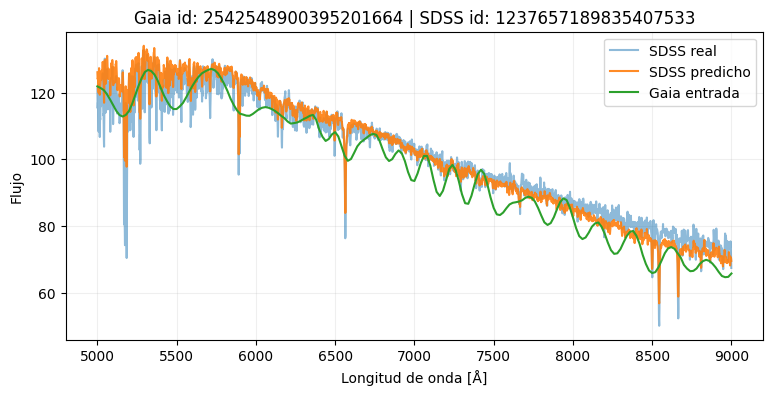

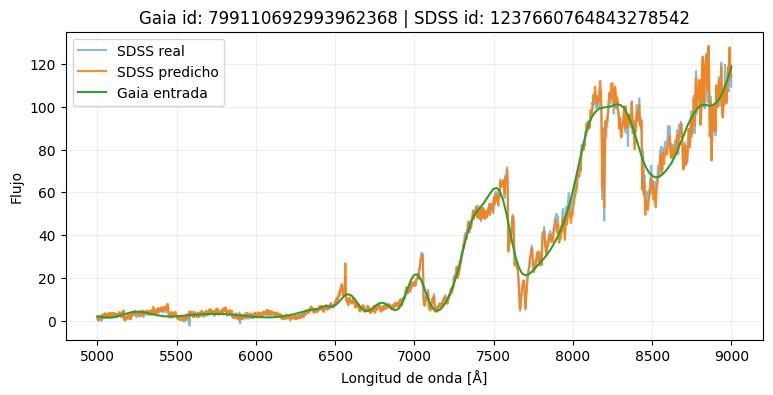

In [29]:
plot_prediction_example(
    245,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_median_spec,
    y_id_test,
    X_test,
    X_id_test
)

plot_prediction_example(
    10,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_median_spec,
    y_id_test,
    X_test,
    X_id_test
)

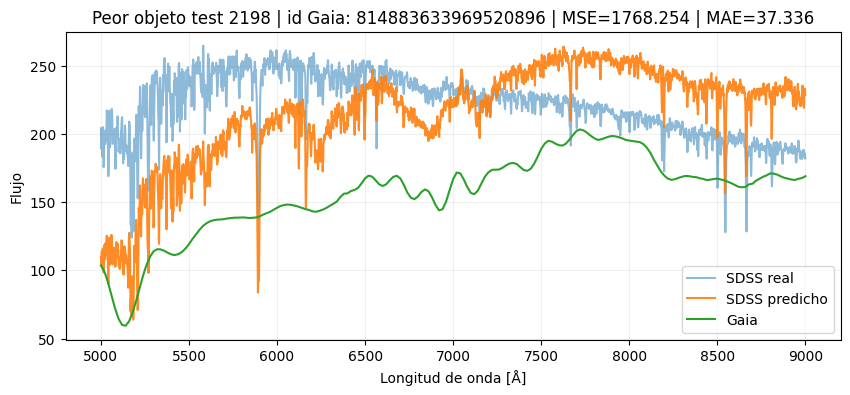

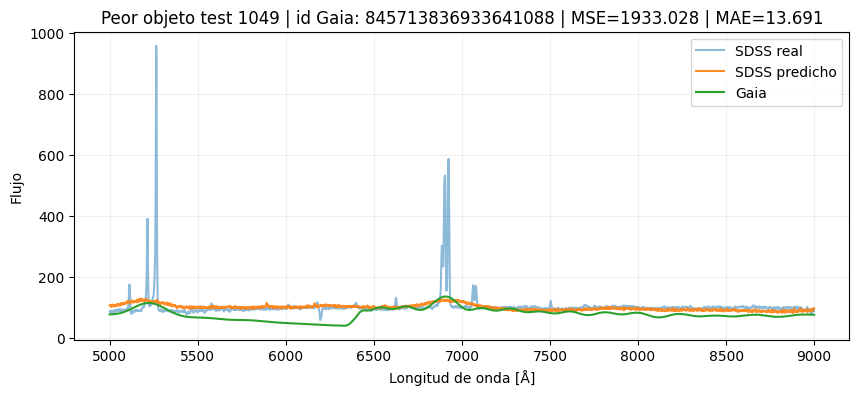

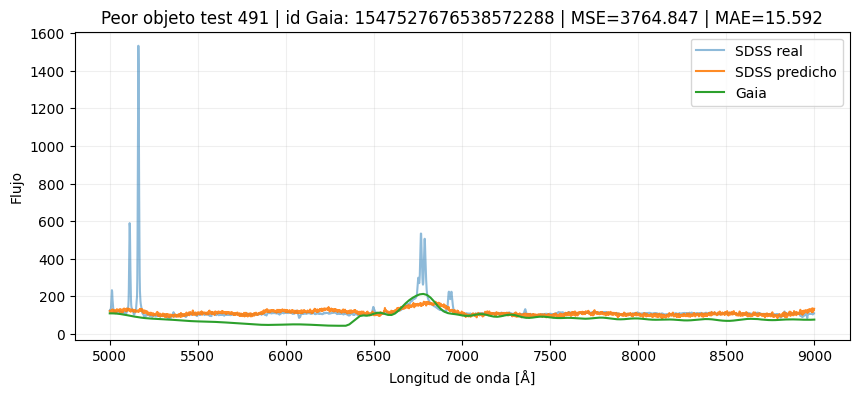

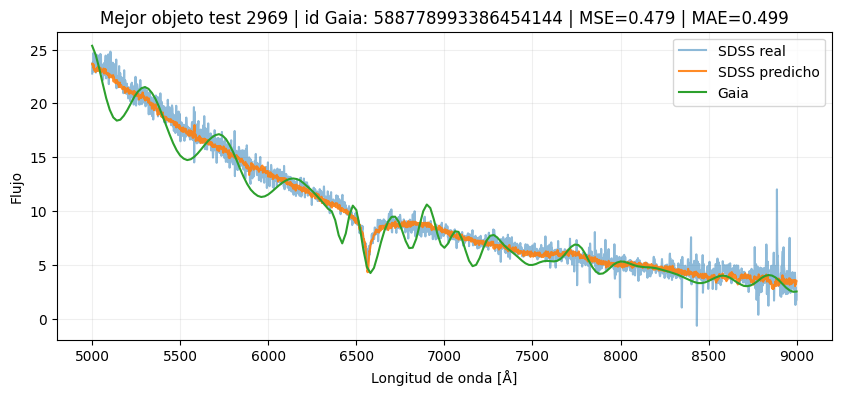

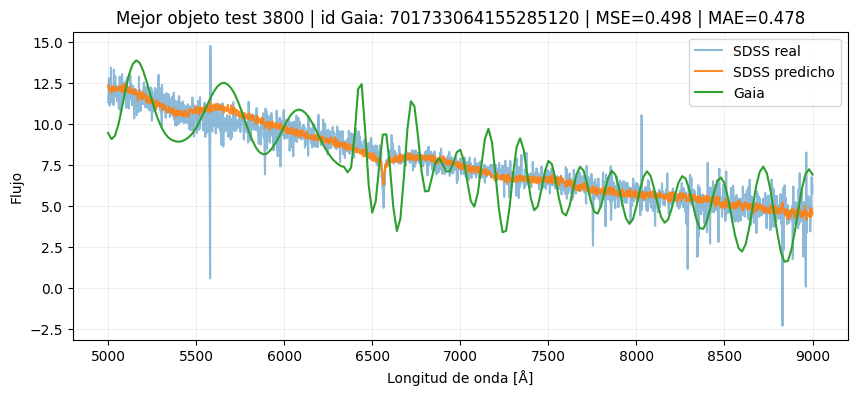

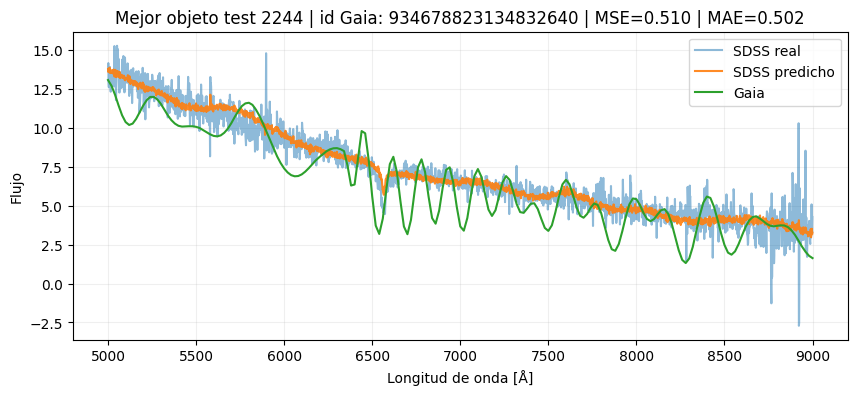

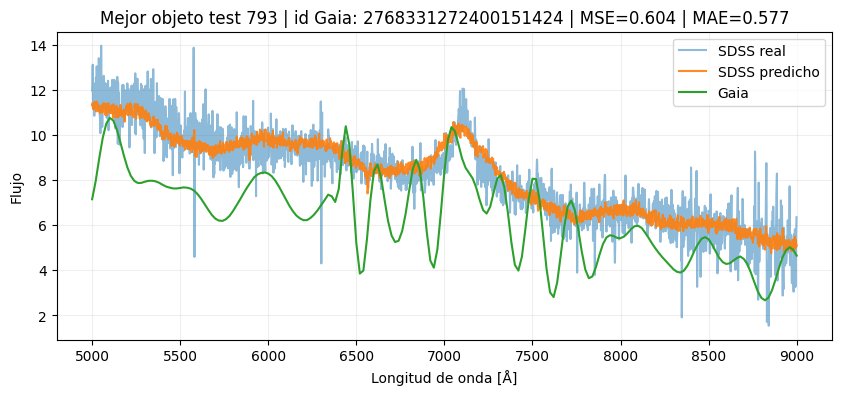

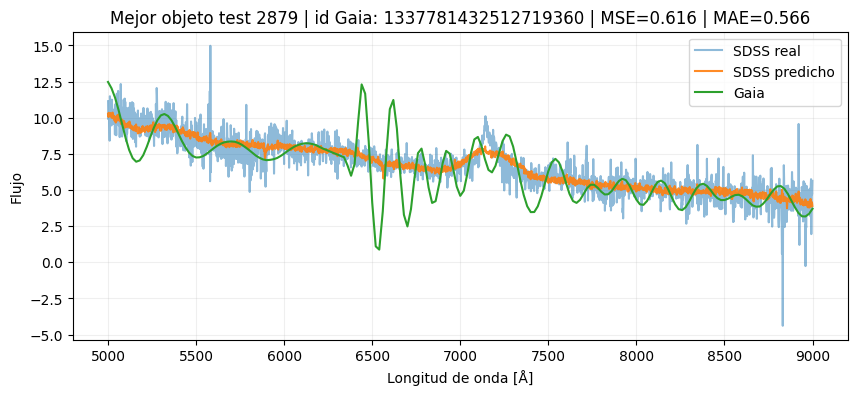

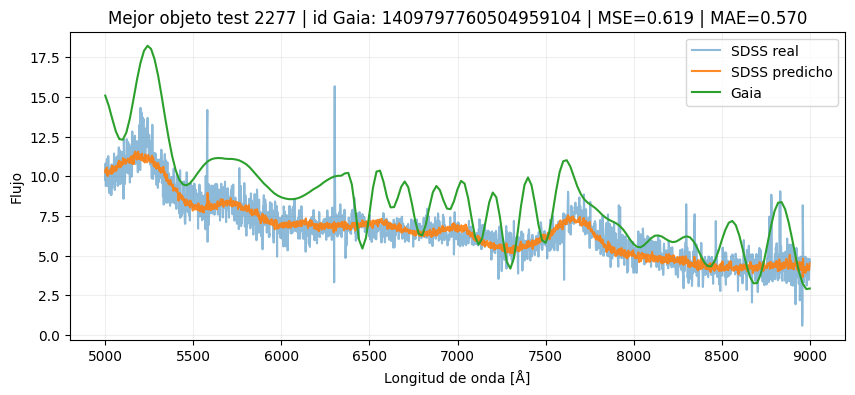

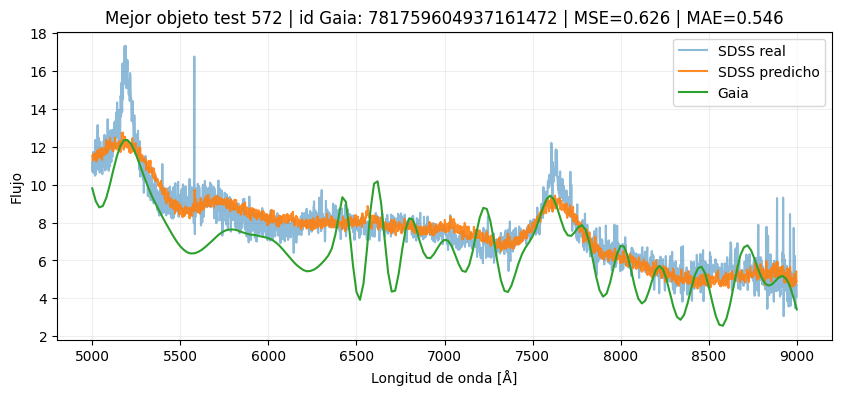

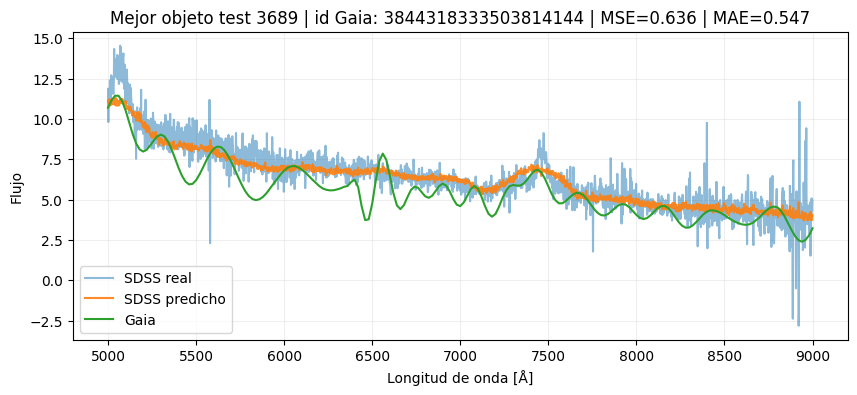

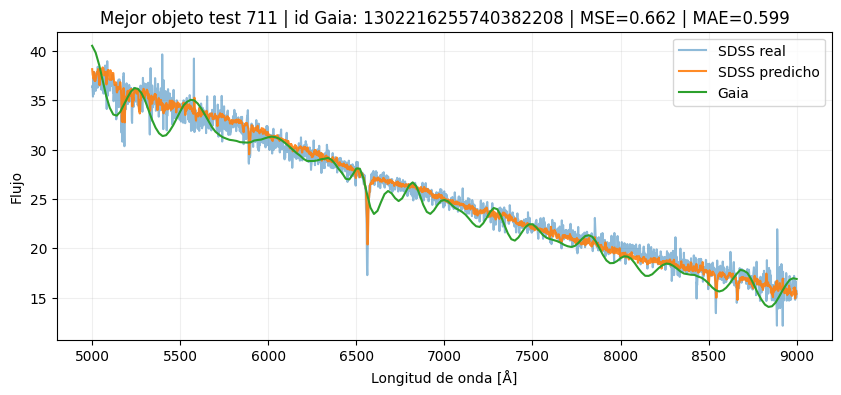

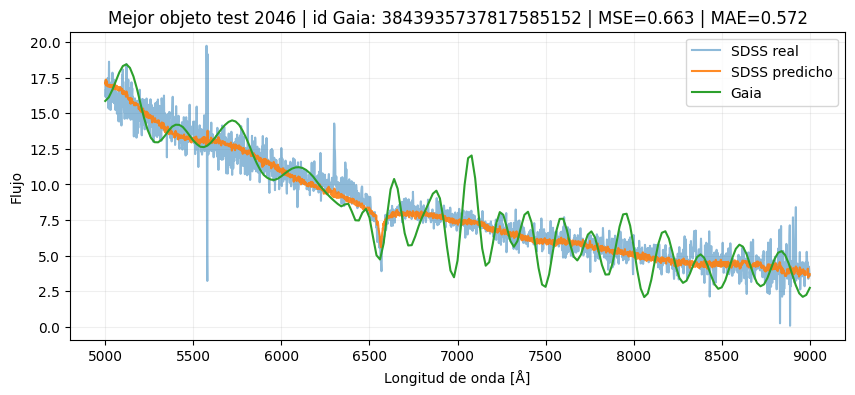

In [30]:
plot_worst_best_predictions(
    y_test,
    y_pred_median_spec,
    X_test,
    X_id_test,
    sdss_wavelength,
    gaia_wavelength,
    3
)

Igual que en el anterior caso, analizamos con iSpec

In [61]:
results_2_df = analyze_sample_real_vs_pred(   
    y_test,
    y_pred_median_spec,
    X_id_test,
    gaia_data_df,
    sdss_wavelength,
    resources,
    sample_size=250
)
display(results_2_df)

Espectros analizados:   0%|          | 0/250 [00:00<?, ?cuerpos estelares/s]

Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
On

[2026-08-23 05:23:38,983] [WARNING] [atmospheres:_interpolate:114]: Target point '3500.0 2.6911155921887264 -4.559396401646393 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-08-23 05:23:42,019] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.
[2026-08-23 05:23:54,144] [WARNING] [atmospheres:_interpolate:114]: Target point '3500.0 2.9241712653553704 -4.433403594384137 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-08-23 05:23:57,174] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.
[2026-08-23 05:24:09,184] [WARNING] [atmospheres:_interpolate:114]: Target point '3538.718101860612 2.1204109244531257 -4.114757058193999 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-2
. . . now exiting to system . . .
[2026-08-2

Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LT

[2026-08-23 07:00:59,324] [WARNING] [atmospheres:_interpolate:114]: Target point '6878.483346679249 4.394249824675197 -5.5 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-08-23 07:01:02,357] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.


Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE


,test_index,source_id,gaia_teff,gaia_logg,gaia_mh,real_teff,real_logg,real_mh,pred_teff,pred_logg,pred_mh,delta_teff,delta_logg,delta_mh
0,63,152047619011614592,5181.031738,4.6678,-0.8967,5289.271388,4.674996,-0.905404,5398.449041,4.750906,-0.997447,109.177653,0.075910,-0.092043
1,3594,1297820202093665792,5753.429688,4.6788,-1.1166,5762.208459,4.675310,-1.125634,5763.089026,4.676549,-1.130464,0.880567,0.001239,-0.004830
2,1248,580515167071431424,6104.623047,4.6595,-1.1587,6105.328300,4.659957,-1.158281,6104.623047,4.659500,-1.158700,-0.705253,-0.000457,-0.000419
3,3984,1548356295989132032,6033.668945,4.1655,-0.6890,6034.768224,4.165740,-0.688687,6036.372485,4.165986,-0.690402,1.604261,0.000246,-0.001715
4,1597,147920842634097664,6010.371582,4.2697,-0.6194,6054.532026,4.361568,-0.892169,6057.752888,4.368376,-0.922928,3.220862,0.006808,-0.030759
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,1845,1385035148035879808,5772.183594,4.5346,-0.9531,5795.581587,4.647755,-0.971190,5814.113858,4.607531,-0.950065,18.532272,-0.040225,0.021125
246,1982,795956503372372096,5929.191406,4.6283,-1.0623,5944.384637,4.706392,-1.937940,5936.027374,4.720054,-2.084636,-8.357263,0.013662,-0.146696
247,199,2541859266085691136,4306.521973,4.5829,0.3544,4615.926600,4.946691,-0.752170,4638.622764,4.998096,-0.748083,22.696164,0.051405,0.004087
248,245,2542548900395201664,5307.782715,4.4148,-0.4674,5334.865702,4.453139,-0.466557,5336.523697,4.460986,-0.469255,1.657996,0.007847,-0.002698


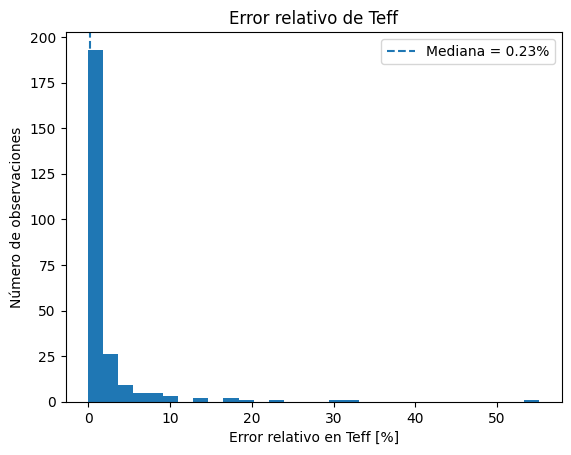

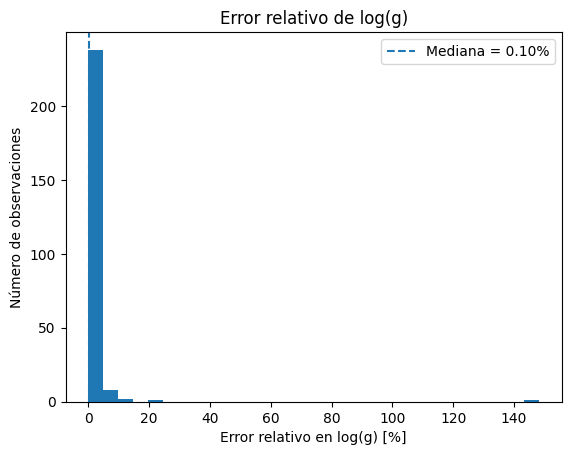

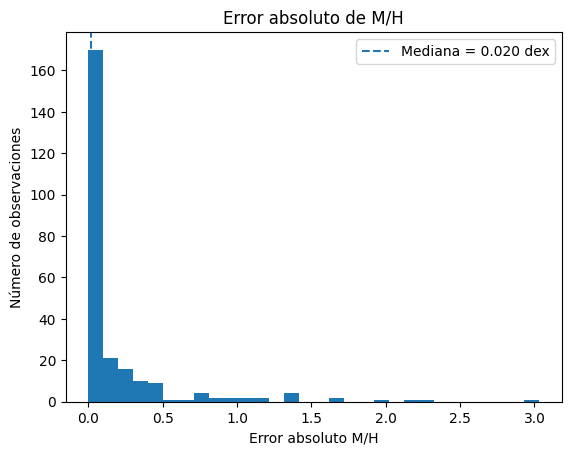

,test_index,source_id,gaia_teff,gaia_logg,gaia_mh,real_teff,real_logg,real_mh,pred_teff,pred_logg,pred_mh,delta_teff,delta_logg,delta_mh,abs_error_teff,abs_error_logg,abs_error_mh,rel_error_teff,rel_error_logg
0,63,152047619011614592,5181.031738,4.6678,-0.8967,5289.271388,4.674996,-0.905404,5398.449041,4.750906,-0.997447,109.177653,0.075910,-0.092043,109.177653,0.075910,0.092043,2.064134,1.623739
1,3594,1297820202093665792,5753.429688,4.6788,-1.1166,5762.208459,4.675310,-1.125634,5763.089026,4.676549,-1.130464,0.880567,0.001239,-0.004830,0.880567,0.001239,0.004830,0.015282,0.026496
2,1248,580515167071431424,6104.623047,4.6595,-1.1587,6105.328300,4.659957,-1.158281,6104.623047,4.659500,-1.158700,-0.705253,-0.000457,-0.000419,0.705253,0.000457,0.000419,0.011551,0.009806
3,3984,1548356295989132032,6033.668945,4.1655,-0.6890,6034.768224,4.165740,-0.688687,6036.372485,4.165986,-0.690402,1.604261,0.000246,-0.001715,1.604261,0.000246,0.001715,0.026584,0.005908
4,1597,147920842634097664,6010.371582,4.2697,-0.6194,6054.532026,4.361568,-0.892169,6057.752888,4.368376,-0.922928,3.220862,0.006808,-0.030759,3.220862,0.006808,0.030759,0.053198,0.156080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,1845,1385035148035879808,5772.183594,4.5346,-0.9531,5795.581587,4.647755,-0.971190,5814.113858,4.607531,-0.950065,18.532272,-0.040225,0.021125,18.532272,0.040225,0.021125,0.319766,0.865468
246,1982,795956503372372096,5929.191406,4.6283,-1.0623,5944.384637,4.706392,-1.937940,5936.027374,4.720054,-2.084636,-8.357263,0.013662,-0.146696,8.357263,0.013662,0.146696,0.140591,0.290291
247,199,2541859266085691136,4306.521973,4.5829,0.3544,4615.926600,4.946691,-0.752170,4638.622764,4.998096,-0.748083,22.696164,0.051405,0.004087,22.696164,0.051405,0.004087,0.491692,1.039177
248,245,2542548900395201664,5307.782715,4.4148,-0.4674,5334.865702,4.453139,-0.466557,5336.523697,4.460986,-0.469255,1.657996,0.007847,-0.002698,1.657996,0.007847,0.002698,0.031078,0.176205


In [64]:
error_2_df = analyze_ispec_errors(results_2_df)
display(error_2_df)

Misma estructura pero con normalización con el máximo por espectro.

In [33]:
# Máximo absoluto por espectro
X_max_train = np.nanmax(np.abs(X_train), axis=1, keepdims=True)
X_max_val = np.nanmax(np.abs(X_val), axis=1, keepdims=True)
X_max_test = np.nanmax(np.abs(X_test), axis=1, keepdims=True)

y_max_train = np.nanmax(np.abs(y_train), axis=1, keepdims=True)
y_max_val = np.nanmax(np.abs(y_val), axis=1, keepdims=True)
y_max_test = np.nanmax(np.abs(y_test), axis=1, keepdims=True)

# Normalización
X_train_norm_max = X_train / X_max_train
X_val_norm_max = X_val / X_max_val
X_test_norm_max = X_test / X_max_test

y_train_norm_max = y_train / y_max_train
y_val_norm_max = y_val / y_max_val
y_test_norm_max = y_test / y_max_test

In [34]:
model_per_spectrum_max = models.Sequential([
    layers.Input(shape=(n_gaia,)),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),
    
    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

model_per_spectrum_max.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm = 1.0),
    loss= tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_per_spectrum_max.summary()

history_max_spectrum = model_per_spectrum_max.fit(
    X_train_norm_max,
    y_train_norm_max,
    validation_data=(X_val_norm_max, y_val_norm_max),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop,reduce_lr],
    verbose=1
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 512)            │       103,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,460,586 (20.83 MB)

 Trainable params: 5,460,586 (20.83 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - loss: 0.0260 - mae: 0.1440 - mse: 0.0520 - val_loss: 0.0056 - val_mae: 0.0690 - val_mse: 0.0112 - learning_rate: 1.0000e-04
Epoch 2/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - loss: 0.0053 - mae: 0.0703 - mse: 0.0105 - val_loss: 0.0063 - val_mae: 0.0727 - val_mse: 0.0126 - learning_rate: 1.0000e-04
Epoch 3/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - loss: 0.0051 - mae: 0.0687 - mse: 0.0101 - val_loss: 0.0053 - val_mae: 0.0690 - val_mse: 0.0107 - learning_rate: 1.0000e-04
Epoch 4/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - loss: 0.0049 - mae: 0.0674 - mse: 0.0098 - val_loss: 0.0049 - val_mae: 0.0678 - val_mse: 0.0099 - learning_rate: 1.0000e-04
Epoch 5/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - loss: 0.0047 - mae: 0.0661 - mse: 0.0095 - val_loss: 0.0050 - val_mae: 0.0672 - val_mse: 0.0100 - learning_rate: 1.0000e-04
Epoch 6/50
510/511 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0046 - mae: 0.0649 - mse: 0.0092
Epoc

In [35]:
y_pred_norm_max = model_per_spectrum_max.predict(X_test_norm_max)
y_pred_per_spectrum_max = y_pred_norm_max * y_max_test

128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [36]:
test_loss_per_spectrum_max, test_mae_per_spectrum_max, test_mse_per_spectrum_max = model_per_spectrum_max.evaluate(
    X_test_norm_max,
    y_test_norm_max,
    verbose=1
)

128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0048 - mae: 0.0625 - mse: 0.0097


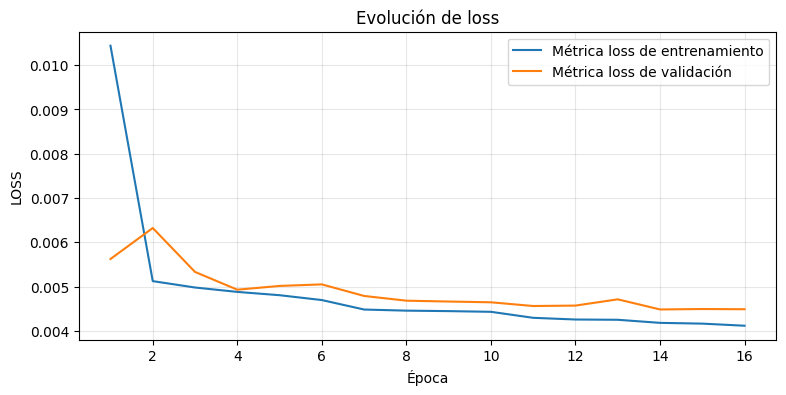

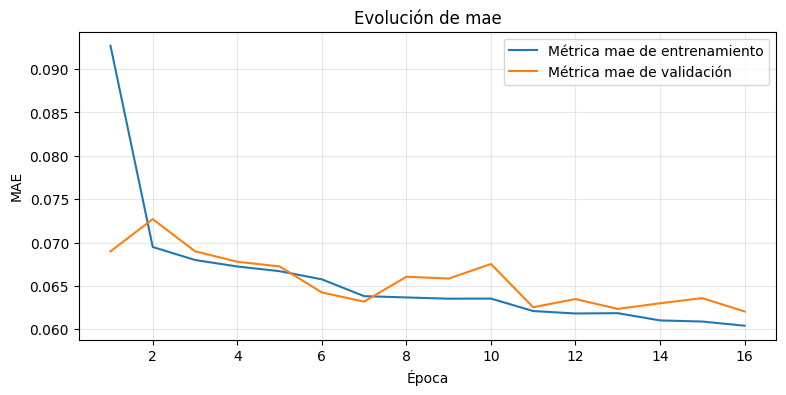

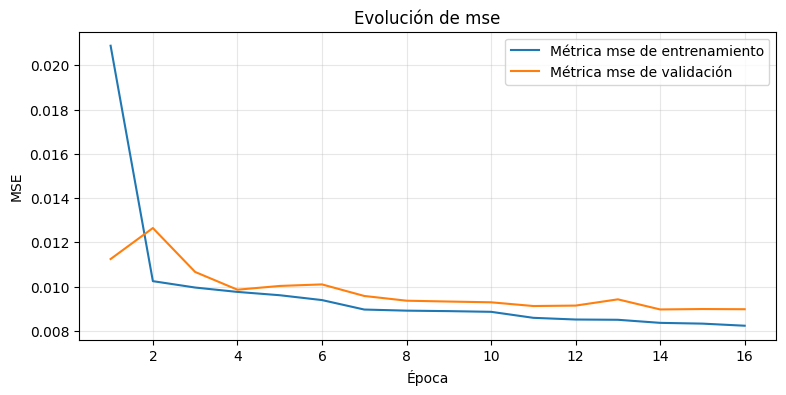

In [37]:
model_data_max = history_max_spectrum.history
plot_training_metrics(model_data_max)


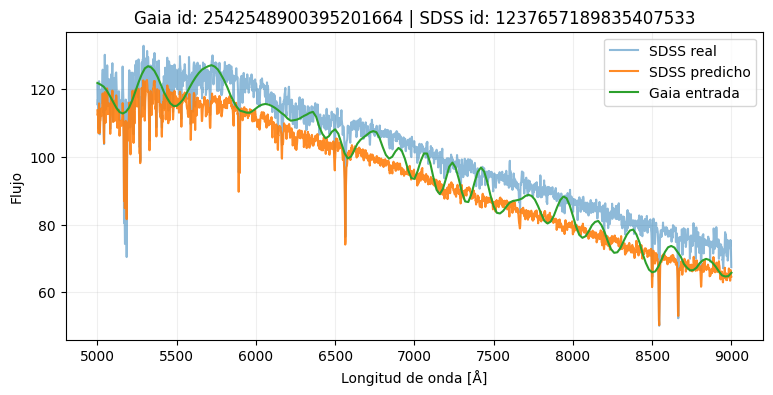

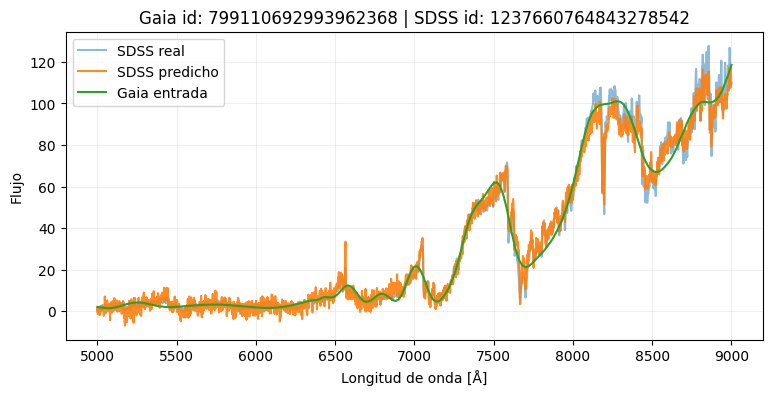

In [38]:
plot_prediction_example(
    245,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_per_spectrum_max,
    y_id_test,
    X_test,
    X_id_test
)

plot_prediction_example(
    10,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_per_spectrum_max,
    y_id_test,
    X_test,
    X_id_test
)

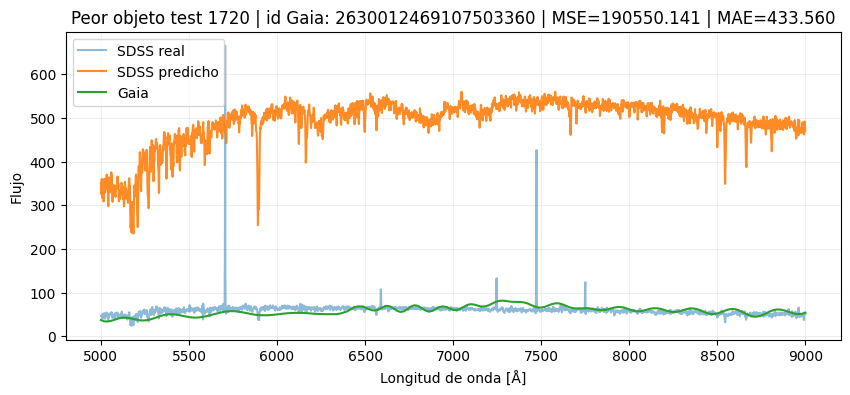

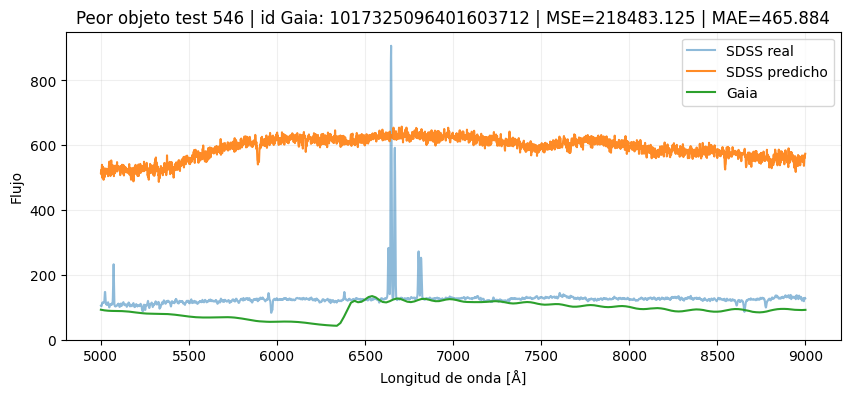

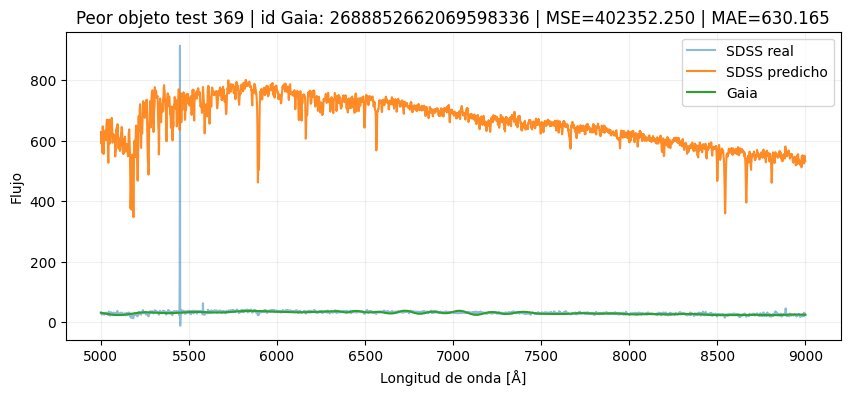

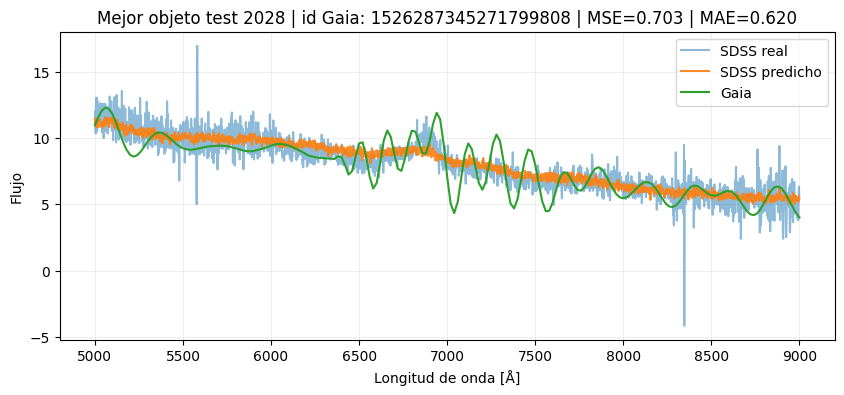

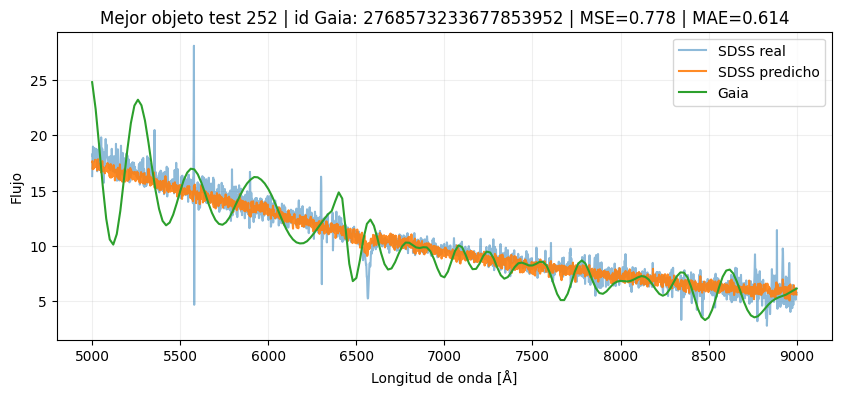

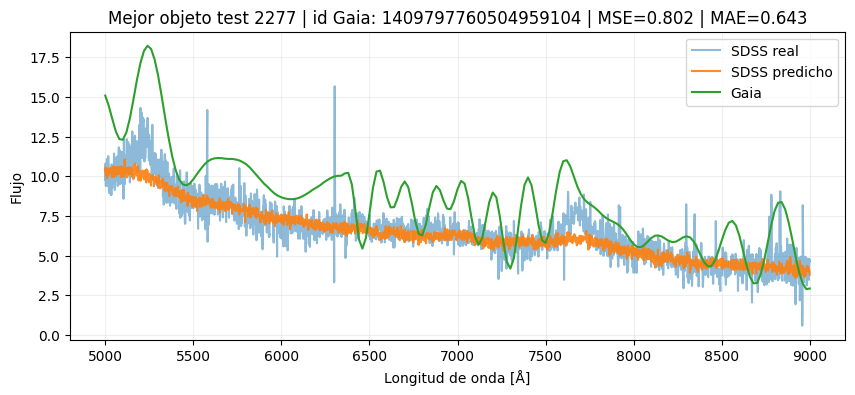

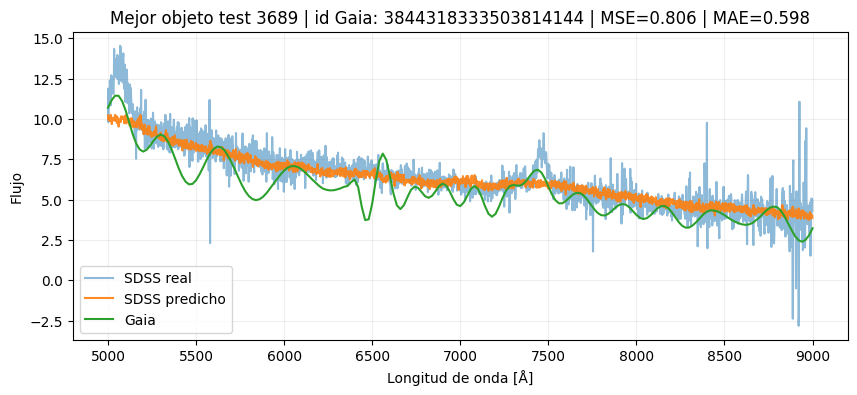

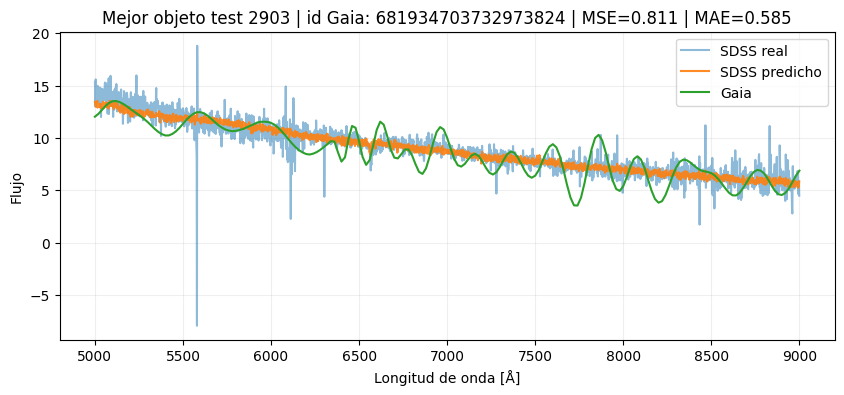

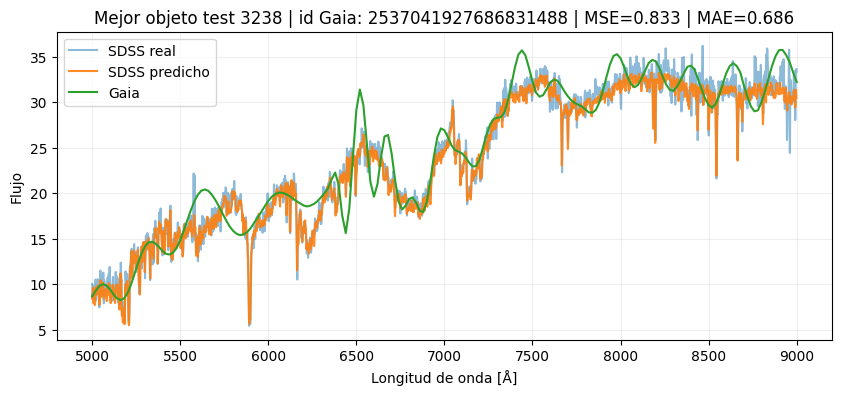

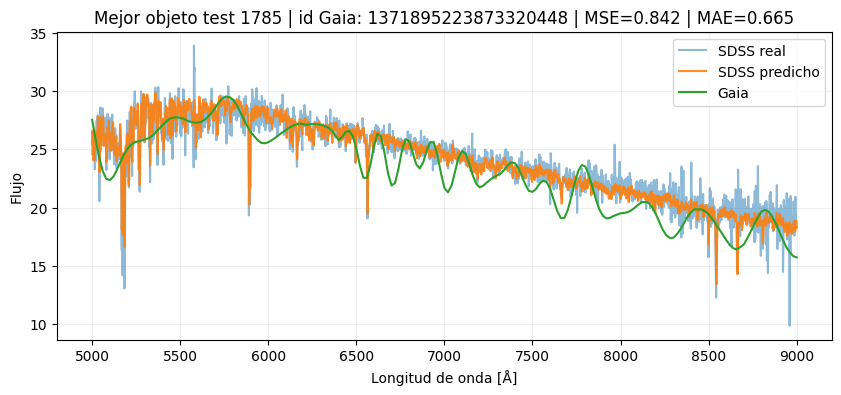

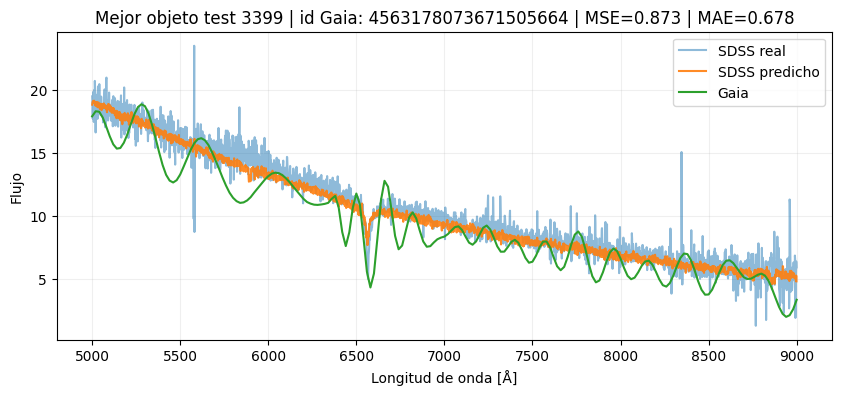

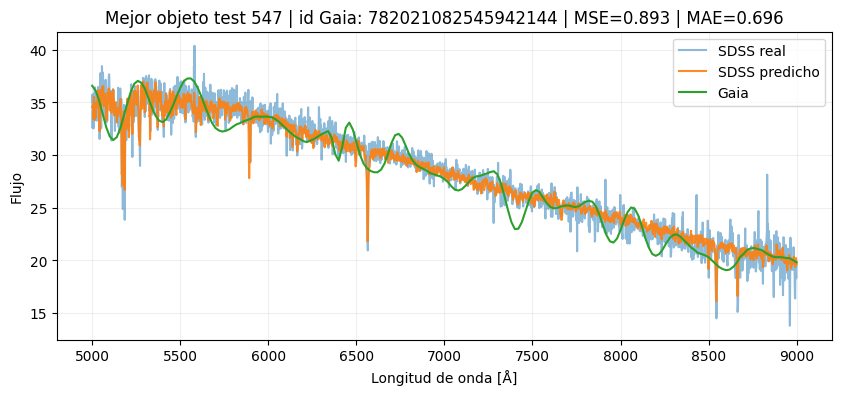

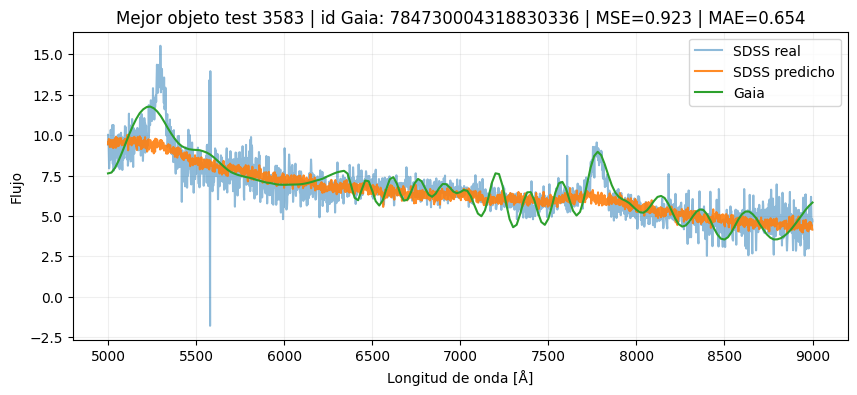

In [39]:
plot_worst_best_predictions(
    y_test,
    y_pred_per_spectrum_max,
    X_test,
    X_id_test,
    sdss_wavelength,
    gaia_wavelength,
    3
)

In [65]:
results_3_df = analyze_sample_real_vs_pred(   
    y_test,
    y_pred_per_spectrum_max,
    X_id_test,
    gaia_data_df,
    sdss_wavelength,
    resources,
    sample_size=250
)
display(results_3_df)

Espectros analizados:   0%|          | 0/250 [00:00<?, ?cuerpos estelares/s]

Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE




Only LTE




Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE

[2026-08-23 12:55:43,787] [WARNING] [atmospheres:_interpolate:114]: Target point '6887.876534015128 4.398775540345566 -5.5 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-08-23 12:55:48,856] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.


Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE


[2026-08-23 14:00:31,389] [WARNING] [atmospheres:_interpolate:114]: Target point '3500.0 2.6911155921887264 -4.559396401646393 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-08-23 14:00:35,445] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.
[2026-08-23 14:00:54,492] [WARNING] [atmospheres:_interpolate:114]: Target point '3500.0 2.9241712653553704 -4.433403594384137 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-08-23 14:00:58,536] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.
[2026-08-23 14:01:17,346] [WARNING] [atmospheres:_interpolate:114]: Target point '3538.718101860612 2.1204109244531257 -4.114757058193999 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-2
. . . now exiting to system . . .
[2026-08-2

Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE


[2026-08-23 15:12:18,852] [WARNING] [atmospheres:_interpolate:114]: Target point '6991.953537139091 4.442605928691038 -5.5 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-08-23 15:12:22,905] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.


Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Only LTE
Error analizando espectro real
Only LTE
Only LTE


,test_index,source_id,gaia_teff,gaia_logg,gaia_mh,real_teff,real_logg,real_mh,pred_teff,pred_logg,pred_mh,delta_teff,delta_logg,delta_mh
0,63,152047619011614592,5181.031738,4.6678,-0.8967,5289.271388,4.674996,-0.905404,5285.846846,4.670244,-0.903540,-3.424542,-0.004752,0.001864
1,3594,1297820202093665792,5753.429688,4.6788,-1.1166,5762.208459,4.675310,-1.125634,5760.183393,4.677716,-1.118823,-2.025066,0.002406,0.006812
2,1248,580515167071431424,6104.623047,4.6595,-1.1587,6105.328300,4.659957,-1.158281,6104.623047,4.659500,-1.158700,-0.705253,-0.000457,-0.000419
3,3984,1548356295989132032,6033.668945,4.1655,-0.6890,6034.768224,4.165740,-0.688687,6035.124139,4.165912,-0.688956,0.355915,0.000173,-0.000269
4,1597,147920842634097664,6010.371582,4.2697,-0.6194,6054.532026,4.361568,-0.892169,6060.498305,4.365430,-0.929024,5.966279,0.003862,-0.036855
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,1612,1767906842245237376,4618.373047,4.6352,-0.2257,4792.523999,5.000000,-1.392463,4479.314334,5.000000,-1.771211,-313.209665,0.000000,-0.378748
246,949,1291094592545363456,5384.086426,4.7029,-0.9961,5418.338661,4.719312,-0.988972,5497.266946,4.693309,-0.996134,78.928286,-0.026003,-0.007162
247,1845,1385035148035879808,5772.183594,4.5346,-0.9531,5795.581587,4.647755,-0.971190,5813.932176,4.606845,-0.949519,18.350589,-0.040910,0.021671
248,1982,795956503372372096,5929.191406,4.6283,-1.0623,5944.384637,4.706392,-1.937940,5997.130086,4.742288,-2.408758,52.745449,0.035897,-0.470818


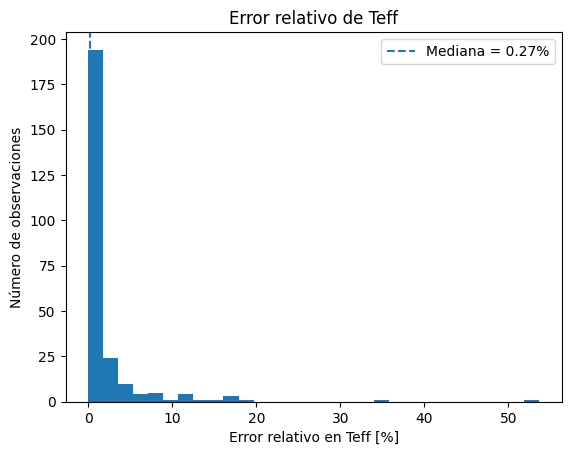

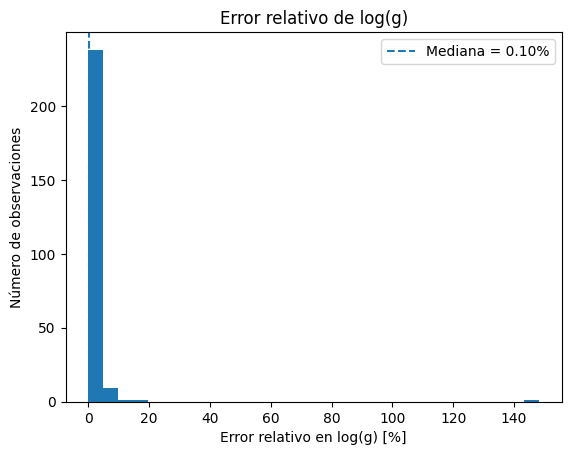

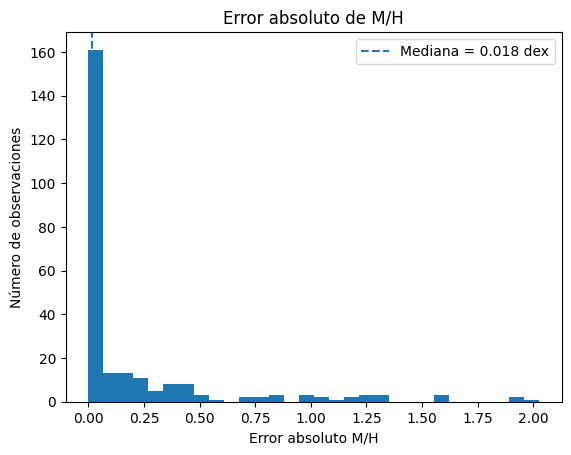

,test_index,source_id,gaia_teff,gaia_logg,gaia_mh,real_teff,real_logg,real_mh,pred_teff,pred_logg,pred_mh,delta_teff,delta_logg,delta_mh,abs_error_teff,abs_error_logg,abs_error_mh,rel_error_teff,rel_error_logg
0,63,152047619011614592,5181.031738,4.6678,-0.8967,5289.271388,4.674996,-0.905404,5285.846846,4.670244,-0.903540,-3.424542,-0.004752,0.001864,3.424542,0.004752,0.001864,0.064745,0.101649
1,3594,1297820202093665792,5753.429688,4.6788,-1.1166,5762.208459,4.675310,-1.125634,5760.183393,4.677716,-1.118823,-2.025066,0.002406,0.006812,2.025066,0.002406,0.006812,0.035144,0.051461
2,1248,580515167071431424,6104.623047,4.6595,-1.1587,6105.328300,4.659957,-1.158281,6104.623047,4.659500,-1.158700,-0.705253,-0.000457,-0.000419,0.705253,0.000457,0.000419,0.011551,0.009806
3,3984,1548356295989132032,6033.668945,4.1655,-0.6890,6034.768224,4.165740,-0.688687,6035.124139,4.165912,-0.688956,0.355915,0.000173,-0.000269,0.355915,0.000173,0.000269,0.005898,0.004146
4,1597,147920842634097664,6010.371582,4.2697,-0.6194,6054.532026,4.361568,-0.892169,6060.498305,4.365430,-0.929024,5.966279,0.003862,-0.036855,5.966279,0.003862,0.036855,0.098542,0.088543
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,1612,1767906842245237376,4618.373047,4.6352,-0.2257,4792.523999,5.000000,-1.392463,4479.314334,5.000000,-1.771211,-313.209665,0.000000,-0.378748,313.209665,0.000000,0.378748,6.535380,0.000000
246,949,1291094592545363456,5384.086426,4.7029,-0.9961,5418.338661,4.719312,-0.988972,5497.266946,4.693309,-0.996134,78.928286,-0.026003,-0.007162,78.928286,0.026003,0.007162,1.456688,0.550993
247,1845,1385035148035879808,5772.183594,4.5346,-0.9531,5795.581587,4.647755,-0.971190,5813.932176,4.606845,-0.949519,18.350589,-0.040910,0.021671,18.350589,0.040910,0.021671,0.316631,0.880220
248,1982,795956503372372096,5929.191406,4.6283,-1.0623,5944.384637,4.706392,-1.937940,5997.130086,4.742288,-2.408758,52.745449,0.035897,-0.470818,52.745449,0.035897,0.470818,0.887316,0.762724


In [66]:
error_3_df = analyze_ispec_errors(results_3_df)
display(error_3_df)

Guardamos las predicciones obtenidas.

In [42]:
predictions_path = Path("../data/predictions/predicciones_modelos_densos.npz")
predictions_path.parent.mkdir(parents=True, exist_ok=True)

np.savez_compressed(
    predictions_path,
    
    # Predicciones de los modelos testeados
    y_pred_global=y_pred_global,
    y_pred_median_spec=y_pred_median_spec,
    y_pred_per_spectrum_max=y_pred_per_spectrum_max
)

In [46]:
data_iSpec = np.load(predictions_path)

print(data_iSpec.files)

['y_pred_global', 'y_pred_median_spec', 'y_pred_per_spectrum_max']


ATLAS9.Castelli
MARCS.GES
